In [4]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

In [6]:
# GPU 사용 여부 확인
import tensorflow as tf
print(tf.__version__)
tf.config.list_physical_devices('GPU')

2.10.0


[]

In [ ]:
# GPU 비활성화
import os
os.environ['CUDA_VISIBLE_DEVICES'] = "-1"

# 1. 기존의 프로그램 방식

In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
def celsius_to_faherenheit(c):
    return 1.8*c + 32

In [10]:
input_data = int(input('섭씨 온도 : '))
print('화씨 온도 :', celsius_to_faherenheit(input_data))

섭씨 온도 : 45
화씨 온도 : 113.0


# 2. 머신러닝/딥러닝 프로그램 방식

1. 데이터 확보 및 생성
2. 데이터 전처리 : 스케일 조정, 라벨링 처리, 데이터셋 분할 [훈련 데이터셋(학습데이터셋), 검증 데이터셋, 시험 데이터셋으로 나누기]
3. 모델 구성
4. 모델 학습과정 설정
5. 모델 학습시키기 (학습 데이터셋과 검증 데이터셋 사용)
6. 모델 평가 (시험 데이터셋 사용)
7. 모델 사용 (입력값을 통해 예측값 받기)

## 2.1 노이즈가 없는 데이터

### 1. 데이터 확보 및 생성

In [12]:
data_C = np.arange(100)
data_C # 입력변수 == 독립변수

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [13]:
data_F = celsius_to_faherenheit(data_C)
data_F # 타겟변수 == 종속변수

array([ 32. ,  33.8,  35.6,  37.4,  39.2,  41. ,  42.8,  44.6,  46.4,
        48.2,  50. ,  51.8,  53.6,  55.4,  57.2,  59. ,  60.8,  62.6,
        64.4,  66.2,  68. ,  69.8,  71.6,  73.4,  75.2,  77. ,  78.8,
        80.6,  82.4,  84.2,  86. ,  87.8,  89.6,  91.4,  93.2,  95. ,
        96.8,  98.6, 100.4, 102.2, 104. , 105.8, 107.6, 109.4, 111.2,
       113. , 114.8, 116.6, 118.4, 120.2, 122. , 123.8, 125.6, 127.4,
       129.2, 131. , 132.8, 134.6, 136.4, 138.2, 140. , 141.8, 143.6,
       145.4, 147.2, 149. , 150.8, 152.6, 154.4, 156.2, 158. , 159.8,
       161.6, 163.4, 165.2, 167. , 168.8, 170.6, 172.4, 174.2, 176. ,
       177.8, 179.6, 181.4, 183.2, 185. , 186.8, 188.6, 190.4, 192.2,
       194. , 195.8, 197.6, 199.4, 201.2, 203. , 204.8, 206.6, 208.4,
       210.2])

### 2. 데이터 전처리 : 스케일 조정 (Normalize)

In [15]:
scaled_data_C = data_C / 100
scaled_data_F = data_F / 100

In [17]:
print('독립변수\n', scaled_data_C)
print('타겟변수\n', scaled_data_F)

독립변수
 [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99]
타겟변수
 [0.32  0.338 0.356 0.374 0.392 0.41  0.428 0.446 0.464 0.482 0.5   0.518
 0.536 0.554 0.572 0.59  0.608 0.626 0.644 0.662 0.68  0.698 0.716 0.734
 0.752 0.77  0.788 0.806 0.824 0.842 0.86  0.878 0.896 0.914 0.932 0.95
 0.968 0.986 1.004 1.022 1.04  1.058 1.076 1.094 1.112 1.13  1.148 1.166
 1.184 1.202 1.22  1.238 1.256 1.274 1.292 1.31  1.328 1.346 1.364 1.382
 1.4   1.418 1.436 1.454 1.472 1.49  1.508 1.526 1.544 1.562 1.58  1.598
 1.616 1.634 1.652 1.67  1.688 1.706 1.724

### 3. 모델 구성
- tensorflow

In [18]:
from tensorflow.keras.models import Sequential # 모델 생성
from tensorflow.keras.layers import Dense, Input # 입력값과 출력값으로 layer층 지정
model = Sequential()
# Dense(전결합) 레이어 추가
model.add(Dense(1, # # 출력 node 개수: 타겟 변수가 1개
               input_shape=(1,) # 입력 데이터의 shape : 입력 특성(Feature)이 1개인 1차원 데이터
               ))
print(model.summary()) # Param # : 파라미터(가중치 W, 편향 b)의 총 개수

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________
None


### 4. 모델 학습과정 설정
- 회귀분석 오차함수 : MSE (오차 제곱 평균), RMSE (오차 제곱 평균의 제곱근), MAE (절댓값 평균)

In [19]:
model.compile(loss='mse', # 손실 함수 : 실제로 최소화해야 할 최우선 오차 목표
              optimizer='rmsprop', # 옵티마이저 : 가중치와 편향을 업데이트하는 알고리즘
              metrics=['mae'] # 평가지표 : 모니터링용 지표
             )

In [21]:
# 학습 전 예측치
model.predict(np.array([[0],[0.01]])) 

1/1 [==============================] - 0s 96ms/step


array([[0.        ],
       [0.01697067]], dtype=float32)

In [23]:
# 학습 전 모델 저장
model.save('model/before_learning.h5') # kernel 내에 w(기울기), bias 내에 b(y절편)이 저장됨

### 5. 모델 학습시키기

In [24]:
hist = model.fit(scaled_data_C, # 독립변수
                 scaled_data_F, # 타겟변수
                 epochs=1000, # 학습 횟수
                 verbose=2) # 학습 과정의 출력을 제어

Epoch 1/1000
4/4 - 0s - loss: 0.1351 - mae: 0.3664 - 272ms/epoch - 68ms/step
Epoch 2/1000
4/4 - 0s - loss: 0.1267 - mae: 0.3550 - 12ms/epoch - 3ms/step
Epoch 3/1000
4/4 - 0s - loss: 0.1211 - mae: 0.3471 - 3ms/epoch - 626us/step
Epoch 4/1000
4/4 - 0s - loss: 0.1165 - mae: 0.3405 - 8ms/epoch - 2ms/step
Epoch 5/1000
4/4 - 0s - loss: 0.1120 - mae: 0.3339 - 2ms/epoch - 551us/step
Epoch 6/1000
4/4 - 0s - loss: 0.1079 - mae: 0.3278 - 7ms/epoch - 2ms/step
Epoch 7/1000
4/4 - 0s - loss: 0.1040 - mae: 0.3219 - 10ms/epoch - 2ms/step
Epoch 8/1000
4/4 - 0s - loss: 0.1001 - mae: 0.3158 - 0s/epoch - 0s/step
Epoch 9/1000
4/4 - 0s - loss: 0.0964 - mae: 0.3099 - 15ms/epoch - 4ms/step
Epoch 10/1000
4/4 - 0s - loss: 0.0927 - mae: 0.3040 - 0s/epoch - 0s/step
Epoch 11/1000
4/4 - 0s - loss: 0.0893 - mae: 0.2983 - 0s/epoch - 0s/step
Epoch 12/1000
4/4 - 0s - loss: 0.0858 - mae: 0.2926 - 0s/epoch - 0s/step
Epoch 13/1000
4/4 - 0s - loss: 0.0824 - mae: 0.2867 - 0s/epoch - 0s/step
Epoch 14/1000
4/4 - 0s - loss: 0.0

4/4 - 0s - loss: 2.1506e-06 - mae: 0.0012 - 11ms/epoch - 3ms/step
Epoch 110/1000
4/4 - 0s - loss: 9.0778e-07 - mae: 8.1838e-04 - 6ms/epoch - 2ms/step
Epoch 111/1000
4/4 - 0s - loss: 4.1875e-07 - mae: 5.4872e-04 - 5ms/epoch - 1ms/step
Epoch 112/1000
4/4 - 0s - loss: 3.5025e-07 - mae: 4.7194e-04 - 0s/epoch - 0s/step
Epoch 113/1000
4/4 - 0s - loss: 5.1854e-07 - mae: 6.6123e-04 - 0s/epoch - 0s/step
Epoch 114/1000
4/4 - 0s - loss: 9.6693e-07 - mae: 9.4631e-04 - 0s/epoch - 0s/step
Epoch 115/1000
4/4 - 0s - loss: 4.3208e-07 - mae: 6.2297e-04 - 8ms/epoch - 2ms/step
Epoch 116/1000
4/4 - 0s - loss: 5.5074e-07 - mae: 7.1919e-04 - 9ms/epoch - 2ms/step
Epoch 117/1000
4/4 - 0s - loss: 5.4305e-07 - mae: 7.1761e-04 - 0s/epoch - 0s/step
Epoch 118/1000
4/4 - 0s - loss: 7.5537e-07 - mae: 8.4795e-04 - 0s/epoch - 0s/step
Epoch 119/1000
4/4 - 0s - loss: 5.4839e-07 - mae: 7.2481e-04 - 2ms/epoch - 623us/step
Epoch 120/1000
4/4 - 0s - loss: 7.3081e-08 - mae: 2.6147e-04 - 0s/epoch - 0s/step
Epoch 121/1000
4/4 -

4/4 - 0s - loss: 6.6334e-07 - mae: 7.5926e-04 - 1ms/epoch - 366us/step
Epoch 209/1000
4/4 - 0s - loss: 1.2674e-07 - mae: 3.4971e-04 - 0s/epoch - 0s/step
Epoch 210/1000
4/4 - 0s - loss: 2.6309e-07 - mae: 4.8858e-04 - 17ms/epoch - 4ms/step
Epoch 211/1000
4/4 - 0s - loss: 1.3517e-06 - mae: 0.0011 - 5ms/epoch - 1ms/step
Epoch 212/1000
4/4 - 0s - loss: 2.7621e-07 - mae: 5.1570e-04 - 7ms/epoch - 2ms/step
Epoch 213/1000
4/4 - 0s - loss: 1.5372e-07 - mae: 3.7439e-04 - 4ms/epoch - 1ms/step
Epoch 214/1000
4/4 - 0s - loss: 1.0895e-06 - mae: 0.0010 - 0s/epoch - 0s/step
Epoch 215/1000
4/4 - 0s - loss: 2.8037e-07 - mae: 5.1848e-04 - 15ms/epoch - 4ms/step
Epoch 216/1000
4/4 - 0s - loss: 5.5672e-07 - mae: 7.2611e-04 - 0s/epoch - 0s/step
Epoch 217/1000
4/4 - 0s - loss: 5.5804e-07 - mae: 7.3274e-04 - 0s/epoch - 0s/step
Epoch 218/1000
4/4 - 0s - loss: 5.2173e-07 - mae: 7.0560e-04 - 3ms/epoch - 686us/step
Epoch 219/1000
4/4 - 0s - loss: 2.2329e-07 - mae: 4.4923e-04 - 7ms/epoch - 2ms/step
Epoch 220/1000
4/

Epoch 307/1000
4/4 - 0s - loss: 1.2292e-06 - mae: 0.0011 - 0s/epoch - 0s/step
Epoch 308/1000
4/4 - 0s - loss: 8.7526e-07 - mae: 8.4919e-04 - 0s/epoch - 0s/step
Epoch 309/1000
4/4 - 0s - loss: 8.1569e-08 - mae: 2.7114e-04 - 0s/epoch - 0s/step
Epoch 310/1000
4/4 - 0s - loss: 1.5647e-07 - mae: 3.7874e-04 - 0s/epoch - 0s/step
Epoch 311/1000
4/4 - 0s - loss: 8.4416e-07 - mae: 8.6479e-04 - 6ms/epoch - 1ms/step
Epoch 312/1000
4/4 - 0s - loss: 9.2286e-07 - mae: 9.2956e-04 - 0s/epoch - 0s/step
Epoch 313/1000
4/4 - 0s - loss: 5.2908e-07 - mae: 7.0317e-04 - 0s/epoch - 0s/step
Epoch 314/1000
4/4 - 0s - loss: 1.2196e-07 - mae: 3.4224e-04 - 17ms/epoch - 4ms/step
Epoch 315/1000
4/4 - 0s - loss: 6.7778e-07 - mae: 7.9881e-04 - 0s/epoch - 0s/step
Epoch 316/1000
4/4 - 0s - loss: 7.9005e-07 - mae: 8.6384e-04 - 11ms/epoch - 3ms/step
Epoch 317/1000
4/4 - 0s - loss: 1.1720e-06 - mae: 9.9020e-04 - 4ms/epoch - 985us/step
Epoch 318/1000
4/4 - 0s - loss: 6.7813e-08 - mae: 2.5528e-04 - 0s/epoch - 0s/step
Epoch 31

4/4 - 0s - loss: 3.0891e-07 - mae: 5.3076e-04 - 0s/epoch - 0s/step
Epoch 406/1000
4/4 - 0s - loss: 1.2047e-06 - mae: 0.0011 - 0s/epoch - 0s/step
Epoch 407/1000
4/4 - 0s - loss: 1.8519e-07 - mae: 4.2193e-04 - 12ms/epoch - 3ms/step
Epoch 408/1000
4/4 - 0s - loss: 6.3185e-07 - mae: 7.7121e-04 - 440us/epoch - 110us/step
Epoch 409/1000
4/4 - 0s - loss: 8.0500e-07 - mae: 8.7216e-04 - 0s/epoch - 0s/step
Epoch 410/1000
4/4 - 0s - loss: 8.3064e-07 - mae: 8.7002e-04 - 0s/epoch - 0s/step
Epoch 411/1000
4/4 - 0s - loss: 6.1672e-09 - mae: 6.3190e-05 - 1ms/epoch - 326us/step
Epoch 412/1000
4/4 - 0s - loss: 4.0390e-08 - mae: 1.7995e-04 - 0s/epoch - 0s/step
Epoch 413/1000
4/4 - 0s - loss: 1.4746e-06 - mae: 0.0011 - 0s/epoch - 0s/step
Epoch 414/1000
4/4 - 0s - loss: 4.7110e-07 - mae: 6.5281e-04 - 17ms/epoch - 4ms/step
Epoch 415/1000
4/4 - 0s - loss: 1.0816e-07 - mae: 3.2208e-04 - 0s/epoch - 0s/step
Epoch 416/1000
4/4 - 0s - loss: 7.4238e-07 - mae: 8.3190e-04 - 0s/epoch - 0s/step
Epoch 417/1000
4/4 - 0s

Epoch 505/1000
4/4 - 0s - loss: 2.6314e-07 - mae: 4.9903e-04 - 8ms/epoch - 2ms/step
Epoch 506/1000
4/4 - 0s - loss: 3.1649e-07 - mae: 5.4796e-04 - 0s/epoch - 0s/step
Epoch 507/1000
4/4 - 0s - loss: 5.5802e-08 - mae: 2.0999e-04 - 0s/epoch - 0s/step
Epoch 508/1000
4/4 - 0s - loss: 1.1138e-06 - mae: 9.8031e-04 - 0s/epoch - 0s/step
Epoch 509/1000
4/4 - 0s - loss: 9.4612e-07 - mae: 8.8377e-04 - 0s/epoch - 0s/step
Epoch 510/1000
4/4 - 0s - loss: 1.5757e-07 - mae: 3.8167e-04 - 0s/epoch - 0s/step
Epoch 511/1000
4/4 - 0s - loss: 3.2020e-07 - mae: 5.4811e-04 - 17ms/epoch - 4ms/step
Epoch 512/1000
4/4 - 0s - loss: 1.1658e-06 - mae: 0.0011 - 0s/epoch - 0s/step
Epoch 513/1000
4/4 - 0s - loss: 2.5491e-07 - mae: 4.9367e-04 - 0s/epoch - 0s/step
Epoch 514/1000
4/4 - 0s - loss: 2.2581e-07 - mae: 4.5686e-04 - 17ms/epoch - 4ms/step
Epoch 515/1000
4/4 - 0s - loss: 1.1178e-06 - mae: 0.0010 - 0s/epoch - 0s/step
Epoch 516/1000
4/4 - 0s - loss: 7.8122e-07 - mae: 8.1865e-04 - 13ms/epoch - 3ms/step
Epoch 517/100

4/4 - 0s - loss: 1.1360e-06 - mae: 0.0010 - 0s/epoch - 0s/step
Epoch 605/1000
4/4 - 0s - loss: 4.8249e-07 - mae: 6.6683e-04 - 0s/epoch - 0s/step
Epoch 606/1000
4/4 - 0s - loss: 3.7558e-07 - mae: 5.9828e-04 - 17ms/epoch - 4ms/step
Epoch 607/1000
4/4 - 0s - loss: 2.5186e-07 - mae: 4.8930e-04 - 0s/epoch - 0s/step
Epoch 608/1000
4/4 - 0s - loss: 1.0410e-06 - mae: 0.0010 - 0s/epoch - 0s/step
Epoch 609/1000
4/4 - 0s - loss: 8.7750e-07 - mae: 8.6479e-04 - 17ms/epoch - 4ms/step
Epoch 610/1000
4/4 - 0s - loss: 2.9003e-07 - mae: 5.2708e-04 - 0s/epoch - 0s/step
Epoch 611/1000
4/4 - 0s - loss: 2.6157e-07 - mae: 4.9856e-04 - 0s/epoch - 0s/step
Epoch 612/1000
4/4 - 0s - loss: 1.0092e-06 - mae: 9.8331e-04 - 17ms/epoch - 4ms/step
Epoch 613/1000
4/4 - 0s - loss: 6.3537e-07 - mae: 7.7150e-04 - 0s/epoch - 0s/step
Epoch 614/1000
4/4 - 0s - loss: 3.8162e-07 - mae: 6.0360e-04 - 0s/epoch - 0s/step
Epoch 615/1000
4/4 - 0s - loss: 8.4927e-07 - mae: 8.9692e-04 - 17ms/epoch - 4ms/step
Epoch 616/1000
4/4 - 0s - l

Epoch 704/1000
4/4 - 0s - loss: 3.2645e-07 - mae: 5.4751e-04 - 16ms/epoch - 4ms/step
Epoch 705/1000
4/4 - 0s - loss: 1.1770e-06 - mae: 0.0011 - 0s/epoch - 0s/step
Epoch 706/1000
4/4 - 0s - loss: 2.6458e-07 - mae: 5.0399e-04 - 0s/epoch - 0s/step
Epoch 707/1000
4/4 - 0s - loss: 1.1622e-07 - mae: 3.2763e-04 - 17ms/epoch - 4ms/step
Epoch 708/1000
4/4 - 0s - loss: 4.0616e-07 - mae: 5.8315e-04 - 0s/epoch - 0s/step
Epoch 709/1000
4/4 - 0s - loss: 1.4565e-06 - mae: 0.0012 - 0s/epoch - 0s/step
Epoch 710/1000
4/4 - 0s - loss: 1.2366e-07 - mae: 3.4552e-04 - 0s/epoch - 0s/step
Epoch 711/1000
4/4 - 0s - loss: 2.7138e-07 - mae: 5.0287e-04 - 0s/epoch - 0s/step
Epoch 712/1000
4/4 - 0s - loss: 1.3371e-06 - mae: 0.0011 - 17ms/epoch - 4ms/step
Epoch 713/1000
4/4 - 0s - loss: 2.8687e-07 - mae: 5.1906e-04 - 0s/epoch - 0s/step
Epoch 714/1000
4/4 - 0s - loss: 3.9943e-07 - mae: 6.1823e-04 - 0s/epoch - 0s/step
Epoch 715/1000
4/4 - 0s - loss: 5.4214e-07 - mae: 7.1164e-04 - 2ms/epoch - 467us/step
Epoch 716/1000


Epoch 804/1000
4/4 - 0s - loss: 3.2411e-07 - mae: 5.4893e-04 - 0s/epoch - 0s/step
Epoch 805/1000
4/4 - 0s - loss: 9.4582e-07 - mae: 9.5652e-04 - 1ms/epoch - 366us/step
Epoch 806/1000
4/4 - 0s - loss: 3.6904e-07 - mae: 5.9576e-04 - 0s/epoch - 0s/step
Epoch 807/1000
4/4 - 0s - loss: 5.7222e-07 - mae: 7.4222e-04 - 15ms/epoch - 4ms/step
Epoch 808/1000
4/4 - 0s - loss: 2.6023e-07 - mae: 4.9391e-04 - 0s/epoch - 0s/step
Epoch 809/1000
4/4 - 0s - loss: 6.5631e-07 - mae: 7.6596e-04 - 0s/epoch - 0s/step
Epoch 810/1000
4/4 - 0s - loss: 8.5963e-07 - mae: 9.1067e-04 - 17ms/epoch - 4ms/step
Epoch 811/1000
4/4 - 0s - loss: 5.1676e-07 - mae: 7.0361e-04 - 0s/epoch - 0s/step
Epoch 812/1000
4/4 - 0s - loss: 1.9682e-07 - mae: 4.3152e-04 - 0s/epoch - 0s/step
Epoch 813/1000
4/4 - 0s - loss: 1.1163e-06 - mae: 0.0010 - 17ms/epoch - 4ms/step
Epoch 814/1000
4/4 - 0s - loss: 4.6207e-07 - mae: 6.5237e-04 - 0s/epoch - 0s/step
Epoch 815/1000
4/4 - 0s - loss: 3.2120e-07 - mae: 5.5115e-04 - 15ms/epoch - 4ms/step
Epoc

Epoch 904/1000
4/4 - 0s - loss: 1.4538e-06 - mae: 0.0012 - 15ms/epoch - 4ms/step
Epoch 905/1000
4/4 - 0s - loss: 2.7302e-07 - mae: 4.8061e-04 - 0s/epoch - 0s/step
Epoch 906/1000
4/4 - 0s - loss: 3.9184e-07 - mae: 6.0228e-04 - 0s/epoch - 0s/step
Epoch 907/1000
4/4 - 0s - loss: 5.3244e-07 - mae: 7.0929e-04 - 16ms/epoch - 4ms/step
Epoch 908/1000
4/4 - 0s - loss: 7.8349e-07 - mae: 8.6967e-04 - 0s/epoch - 0s/step
Epoch 909/1000
4/4 - 0s - loss: 6.7352e-07 - mae: 7.9143e-04 - 0s/epoch - 0s/step
Epoch 910/1000
4/4 - 0s - loss: 4.0408e-07 - mae: 6.1936e-04 - 17ms/epoch - 4ms/step
Epoch 911/1000
4/4 - 0s - loss: 2.6118e-07 - mae: 4.9545e-04 - 0s/epoch - 0s/step
Epoch 912/1000
4/4 - 0s - loss: 1.1199e-06 - mae: 0.0010 - 0s/epoch - 0s/step
Epoch 913/1000
4/4 - 0s - loss: 6.9367e-07 - mae: 7.9301e-04 - 0s/epoch - 0s/step
Epoch 914/1000
4/4 - 0s - loss: 1.9434e-07 - mae: 4.3186e-04 - 9ms/epoch - 2ms/step
Epoch 915/1000
4/4 - 0s - loss: 2.3200e-07 - mae: 4.5644e-04 - 6ms/epoch - 1ms/step
Epoch 916/1

In [28]:
hist.history.keys()

dict_keys(['loss', 'mae'])

Text(0, 0.5, 'Gap')

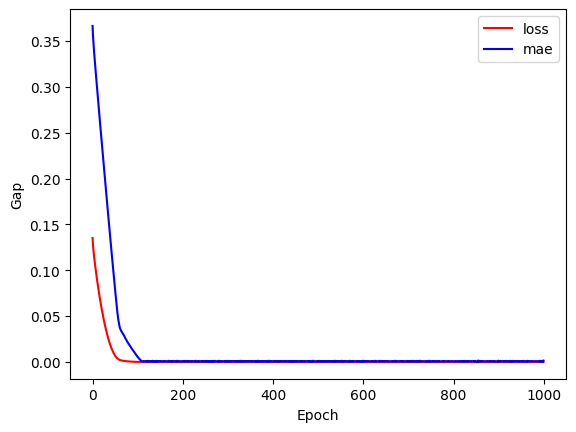

In [34]:
plt.plot(hist.history['loss'], 'r', label='loss')
plt.plot(hist.history['mae'], 'b', label='mae')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Gap')

### 6. 모델 사용하기

In [26]:
# 학습 후 예측치
model.predict(np.array([[0],[0.01]]))

1/1 [==============================] - 0s 19ms/step


array([[0.31953412],
       [0.33753055]], dtype=float32)

In [27]:
# 학습 후 모델 저장
model.save('model/after_learning.h5') # w_hat = 1.7996441, b_hat = 0.31953412